# **Capstone — Analysing Insurance Claims for SafeDrive Insurance Ltd.**

## Task 1.1 — Business Problem & Success Metrics

**Analytical objective:** Build a model that predicts which policyholders are likely to
file a claim during the policy period, using policy, policyholder, and vehicle attributes,
and explain in business terms what drives that risk.

**Expected business outcome:** Underwriting and risk teams can identify high-risk policies
early — supporting risk-based pricing, targeted checks, and reduced claim losses — and
replace inconsistent manual assessment with a consistent, data-driven risk score.

**Target audience:** SafeDrive's underwriting and risk management teams (management-level
consumers of the dashboard and report).

**Business questions:**
1. Do policyholder characteristics (age) and policy characteristics (tenure) relate to
   claim likelihood?
2. Do vehicle safety attributes (NCAP rating, safety features) reduce claim frequency?
3. Are certain geographies (area clusters) systematically riskier than others?

**Business success metrics:**
- Flag the top-risk decile of policyholders so that it captures a disproportionate share
  of actual claims (e.g., ≥2× the average claim rate).
- Provide explainable risk drivers management can act on (pricing, underwriting checks).
- A consistent, reproducible risk-scoring process replacing subjective assessment.

**Model evaluation metrics:**
- **Recall** — only ~6.4% of policies claim; missing a future claimant (false negative)
  costs a payout, while a false alarm costs only a review. Catching claimants is the priority.
- **ROC-AUC** — measures ranking quality across all thresholds, robust to the class
  imbalance; supports risk-decile use of the scores.
- **Precision / F1** — guards against flagging so many customers that underwriting
  review becomes impractical.
- Accuracy is deliberately excluded as primary: predicting "no claim" for everyone scores
  93.6% while being useless.

## Task 1.2 — Load, Inspect and Clean the Dataset

### Data Import


In [1]:
# Task 1.2: Load, inspect and clean data

# Import all necessary libraries
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)


# ------------------------------------------------------------------
# LOAD THE DATASET — robust path resolution
# The file may sit next to the notebook, in the uploads folder, or in
# an archive/ sub-folder, so we search all of them instead of assuming.
# ------------------------------------------------------------------
def resolve_dataset_path(filenames=('dataset.csv', 'Train.csv', 'train.csv'),
                         search_dirs=('.', '/mnt/user-data/uploads', 'archive',
                                      './archive', '..', '../archive')):
    for d in search_dirs:
        for f in filenames:
            candidate = os.path.join(d, f)
            if os.path.exists(candidate):
                return candidate
    raise FileNotFoundError(f"Dataset not found. Searched {search_dirs} for {filenames}")


DATA_PATH = resolve_dataset_path()
print("Loaded from:", DATA_PATH)

ins = pd.read_csv(DATA_PATH)

# INSPECT SHAPE AND SCHEMA
print(f"Dataset Shape: {ins.shape[0]:,} rows x {ins.shape[1]} columns\n")
ins.info()

Loaded from: ./dataset.csv
Dataset Shape: 58,592 rows x 44 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11 

In [2]:
ins.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


### Profile: Schema, Missing Values, Duplicates & Target Balance

Column dtypes:
object     28
int64      12
float64     4
Name: count, dtype: int64 

Missing values per column (showing non-zero only):
  None — no column has missing values
Total missing cells: 0

Exact duplicate rows      : 0
Duplicate policy_id values: 0

Target balance (is_claim):
is_claim
0    54844
1     3748
Name: count, dtype: int64 

is_claim
0    0.936
1    0.064
Name: proportion, dtype: float64 

Class imbalance ratio (No Claim : Claim) = 14.6 : 1
Positive class (claims) = 6.40% of the portfolio


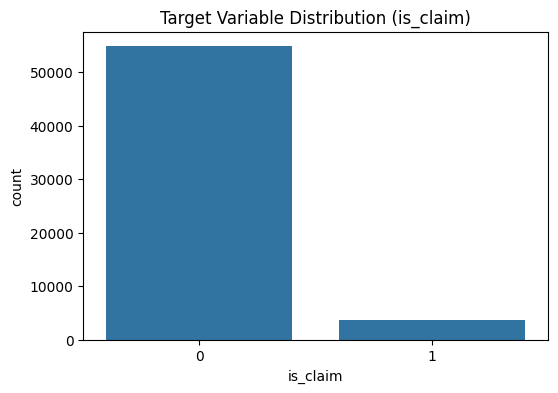

In [3]:
# ---------- 1. Schema profile ----------
print("Column dtypes:")
print(ins.dtypes.value_counts(), "\n")

# ---------- 2. Missing values, per column ----------
nulls = ins.isnull().sum()
print("Missing values per column (showing non-zero only):")
print(nulls[nulls > 0] if (nulls > 0).any() else "  None — no column has missing values")
print(f"Total missing cells: {nulls.sum()}\n")

# ---------- 3. Duplicates ----------
print(f"Exact duplicate rows      : {ins.duplicated().sum()}")
print(f"Duplicate policy_id values: {ins['policy_id'].duplicated().sum()}\n")

# ---------- 4. Target class balance ----------
counts = ins['is_claim'].value_counts()
props  = ins['is_claim'].value_counts(normalize=True).round(4)
print("Target balance (is_claim):")
print(counts, "\n")
print(props, "\n")
print(f"Class imbalance ratio (No Claim : Claim) = {counts[0] / counts[1]:.1f} : 1")
print(f"Positive class (claims) = {props[1] * 100:.2f}% of the portfolio")

# Visual check
plt.figure(figsize=(6, 4))
sns.countplot(data=ins, x='is_claim')
plt.title('Target Variable Distribution (is_claim)')
plt.show()

In [4]:
# ---------- Remove exact duplicate rows ----------
rows_before = ins.shape[0]
ins = ins.drop_duplicates().reset_index(drop=True)
rows_after = ins.shape[0]

print(f"Rows before : {rows_before:,}")
print(f"Rows after  : {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")
print(f"Duplicates remaining: {ins.duplicated().sum()}")

Rows before : 58,592
Rows after  : 58,592
Rows removed: 0
Duplicates remaining: 0


# Interpretation

1. **Schema:** 58,592 policies across 44 columns — a mix of numeric vehicle specifications, `Yes`/`No` safety flags, and text-coded categoricals (`area_cluster`, `segment`, `model`, `engine_type`).

2. **Missing values / duplicates:** No missing values, no exact duplicate rows, and `policy_id` is unique across every record — so no imputation or de-duplication was actually required. The removal step is still run so the pipeline is safe if re-executed on a refreshed extract.

3. **Class balance:** Insurance datasets are typically highly imbalanced, and this one is no exception — only ~6.4% of policies filed a claim, an imbalance of roughly **14.6 : 1**. Accuracy is therefore misleading (predicting "no claim" for everyone scores 93.6%), so we prioritise **recall** and **ROC-AUC**, and will use class weights during modelling.


### Standardise Categorical Labels

`Yes`/`No` columns are detected **by their values, not by their names**, so the step still works if
a flag column is added or renamed in a future data drop. Labels are normalised with
`.str.strip().str.title()` before any encoding, so stray whitespace or casing (`" yes"`, `"NO"`)
cannot silently create extra categories.


In [5]:
# ---------- Detect Yes/No columns programmatically (value-based, not hardcoded) ----------
non_numeric = ins.select_dtypes(exclude=np.number).columns

yes_no_cols = [
    col for col in non_numeric
    if set(ins[col].dropna().astype(str).str.strip().str.title().unique()) <= {'Yes', 'No'}
]

print(f"Detected {len(yes_no_cols)} Yes/No flag columns:")
for c in yes_no_cols:
    print("   ", c)

# ---------- Standardise casing / whitespace ----------
for col in yes_no_cols:
    ins[col] = ins[col].astype(str).str.strip().str.title()

# ---------- Confirm standardisation before encoding ----------
distinct = sorted(set(np.unique(ins[yes_no_cols].values)))
print(f"\nDistinct values across all flag columns after standardisation: {distinct}")
assert distinct == ['No', 'Yes'], "Unexpected value found in a Yes/No column"
print("All binary flag columns are standardised and ready for encoding.")

Detected 17 Yes/No flag columns:
    is_esc
    is_adjustable_steering
    is_tpms
    is_parking_sensors
    is_parking_camera
    is_front_fog_lights
    is_rear_window_wiper
    is_rear_window_washer
    is_rear_window_defogger
    is_brake_assist
    is_power_door_locks
    is_central_locking
    is_power_steering
    is_driver_seat_height_adjustable
    is_day_night_rear_view_mirror
    is_ecw
    is_speed_alert

Distinct values across all flag columns after standardisation: ['No', 'Yes']
All binary flag columns are standardised and ready for encoding.


### Parse Numeric Values from `max_power` and `max_torque`

These arrive as text (`'88.50bhp@6000rpm'`). We pull the leading number into
`max_power_bhp` / `max_torque_nm`, and additionally capture the rpm figure after the `@`,
which is a genuinely separate engine characteristic rather than a duplicate of the first number.


In [6]:
def extract_leading_number(text):
    """Pull the first numeric token out of a string.

    '88.50bhp@6000rpm' -> 88.50
    '60Nm@3500rpm'     -> 60.0
    """
    if pd.isna(text):
        return np.nan
    match = re.search(r'(\d+\.?\d*)', str(text))
    return float(match.group(1)) if match else np.nan


# Leading value: bhp for power, Nm for torque
ins['max_power_bhp'] = ins['max_power'].apply(extract_leading_number)
ins['max_torque_nm'] = ins['max_torque'].apply(extract_leading_number)

# The rpm at which peak power / torque is delivered (number after '@')
ins['power_rpm']  = ins['max_power'].astype(str).str.extract(r'@(\d+)').astype(float)
ins['torque_rpm'] = ins['max_torque'].astype(str).str.extract(r'@(\d+)').astype(float)

# Verify the parse before dropping the source columns
print(ins[['max_power', 'max_power_bhp', 'power_rpm',
           'max_torque', 'max_torque_nm', 'torque_rpm']].head())
print("\nUnparsed values:",
      ins[['max_power_bhp', 'max_torque_nm', 'power_rpm', 'torque_rpm']].isna().sum().sum())

# Drop the original text columns now that the numbers are extracted
ins = ins.drop(columns=['max_power', 'max_torque'])
print("Shape after parsing:", ins.shape)

          max_power  max_power_bhp  power_rpm     max_torque  max_torque_nm  \
0  40.36bhp@6000rpm          40.36     6000.0   60Nm@3500rpm           60.0   
1  40.36bhp@6000rpm          40.36     6000.0   60Nm@3500rpm           60.0   
2  40.36bhp@6000rpm          40.36     6000.0   60Nm@3500rpm           60.0   
3  88.50bhp@6000rpm          88.50     6000.0  113Nm@4400rpm          113.0   
4  67.06bhp@5500rpm          67.06     5500.0   91Nm@4250rpm           91.0   

   torque_rpm  
0      3500.0  
1      3500.0  
2      3500.0  
3      4400.0  
4      4250.0  

Unparsed values: 0
Shape after parsing: (58592, 46)


### Datatype Correction

Any remaining text column that is really a number gets coerced with `pd.to_numeric`.
`policy_id` and the true categoricals are excluded by design — `make` in particular is a
manufacturer **ID**, so it is cast to string to stop it being treated as a quantity in
correlation and VIF calculations later.


In [7]:
# make is a manufacturer identifier, not a measurement — keep it categorical
ins['make'] = ins['make'].astype(str)

ID_COLS = ['policy_id']
coerced = []

for col in ins.select_dtypes(exclude=np.number).columns:
    if col in ID_COLS or col in yes_no_cols or col == 'make':
        continue
    converted = pd.to_numeric(ins[col], errors='coerce')
    # Only accept the conversion if virtually every value parsed cleanly
    if converted.notna().mean() > 0.95:
        ins[col] = converted
        coerced.append(col)

print("Columns coerced to numeric:", coerced if coerced else "none needed")
print("\nRemaining text columns:", ins.select_dtypes(exclude=np.number).columns.tolist())
print("\nDtype summary:")
print(ins.dtypes.value_counts())

Columns coerced to numeric: none needed

Remaining text columns: ['policy_id', 'area_cluster', 'make', 'segment', 'model', 'fuel_type', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']

Dtype summary:
object     27
int64      11
float64     8
Name: count, dtype: int64


### Handling Missing Values

Coercion with `errors='coerce'` can silently turn unparseable text into `NaN`, so we re-check
**after** the datatype step and impute anything it created: **median** for numeric columns
(robust to the skew we are about to measure) and **mode** for categoricals.


In [8]:
num_cols_all = ins.select_dtypes(include=np.number).columns
cat_cols_all = ins.select_dtypes(exclude=np.number).columns

missing_before = ins.isna().sum().sum()
imputed = []

for col in num_cols_all:
    if ins[col].isna().any():
        ins[col] = ins[col].fillna(ins[col].median())
        imputed.append((col, 'median'))

for col in cat_cols_all:
    if ins[col].isna().any():
        ins[col] = ins[col].fillna(ins[col].mode()[0])
        imputed.append((col, 'mode'))

print(f"Missing cells before imputation: {missing_before}")
print(f"Columns imputed: {imputed if imputed else 'none — no missing values were present'}")
print(f"Missing cells after imputation : {ins.isna().sum().sum()}")

Missing cells before imputation: 0
Columns imputed: none — no missing values were present
Missing cells after imputation : 0


## Outlier Detection and Treatment

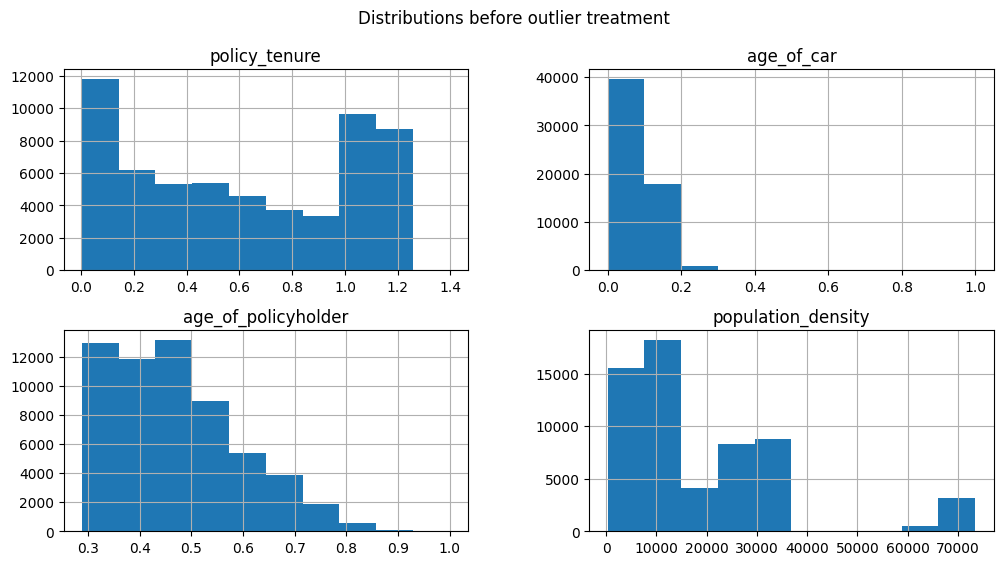

In [9]:
num_cols = ['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density']

ins[num_cols].hist(figsize=(12, 6))
plt.suptitle('Distributions before outlier treatment')
plt.show()

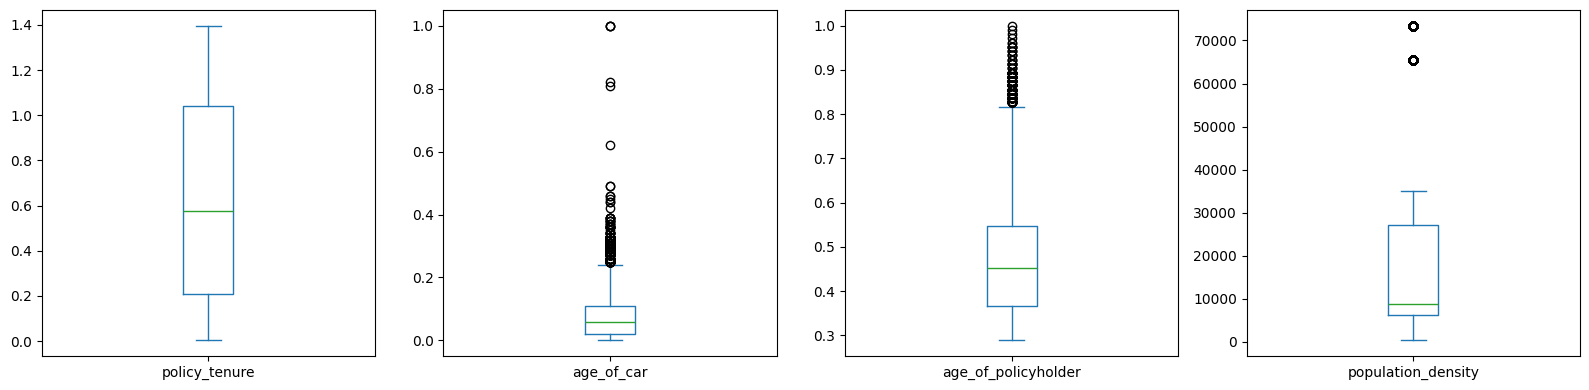

In [10]:
ins[num_cols].plot(kind='box', subplots=True, layout=(1, 4), figsize=(16, 4))
plt.tight_layout()
plt.show()

In [11]:
# ---------- Outlier Detection — IQR method across ALL numeric features ----------
# Excluded: the target, identifiers, and flag-like columns (<=2 distinct values),
# because an IQR fence is meaningless on a 0/1 column.

flag_like = [c for c in ins.select_dtypes(include=np.number).columns
             if ins[c].dropna().nunique() <= 2]

outlier_cols = [c for c in ins.select_dtypes(include=np.number).columns
                if c != 'is_claim' and c not in flag_like]

print(f"Scanning {len(outlier_cols)} numeric columns "
      f"(excluded target + {len(flag_like)} flag-like columns)\n")

report = []
for col in outlier_cols:
    Q1, Q3 = ins[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((ins[col] < lower) | (ins[col] > upper)).sum()
    report.append({'column': col, 'n_outliers': n_out,
                   'pct': round(n_out / len(ins) * 100, 2),
                   'lower_fence': round(lower, 2), 'upper_fence': round(upper, 2)})

outlier_report = pd.DataFrame(report).sort_values('n_outliers', ascending=False)
print(outlier_report.to_string(index=False))

Scanning 16 numeric columns (excluded target + 3 flag-like columns)

             column  n_outliers  pct  lower_fence  upper_fence
 population_density        3647 6.22    -25224.50     58339.50
         age_of_car         269 0.46        -0.12         0.24
age_of_policyholder         221 0.38         0.09         0.82
      policy_tenure           0 0.00        -1.03         2.28
            airbags           0 0.00        -4.00        12.00
       displacement           0 0.00      -249.50      2538.50
     turning_radius           0 0.00         4.00         5.60
             length           0 0.00      2620.00      4820.00
              width           0 0.00      1155.00      2115.00
             height           0 0.00      1235.00      1875.00
       gross_weight           0 0.00       697.50      1997.50
        ncap_rating           0 0.00        -4.50         7.50
      max_power_bhp           0 0.00       -45.94       184.19
      max_torque_nm           0 0.00      -150.00

In [12]:
# Are the Outliers Errors or Signal?

for col in ['age_of_car', 'age_of_policyholder', 'population_density']:
    Q1, Q3 = ins[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    mask = (ins[col] < Q1 - 1.5*IQR) | (ins[col] > Q3 + 1.5*IQR)
    print(col, "→ outlier claim rate:", round(ins.loc[mask, 'is_claim'].mean(), 4),
          "| overall:", round(ins['is_claim'].mean(), 4))

age_of_car → outlier claim rate: 0.0335 | overall: 0.064
age_of_policyholder → outlier claim rate: 0.1312 | overall: 0.064
population_density → outlier claim rate: 0.0458 | overall: 0.064


In [13]:
# Verify density is a cluster-level attribute: few unique values, one per area
print(ins['population_density'].nunique(), "unique density values across",
      ins['area_cluster'].nunique(), "area clusters")

# Recompute this column's fence — `upper` is stale from the detection loop above.

Q1, Q3 = ins['population_density'].quantile([0.25, 0.75])
density_upper = Q3 + 1.5 * (Q3 - Q1)
flagged = ins[ins['population_density'] > density_upper]

# Concentration in few clusters => cluster-level attribute, not data errors.

print(f"\nUpper IQR fence for population_density: {density_upper:,.1f}")
print(f"Policies above the fence: {len(flagged):,}")
print("\nArea clusters they belong to:")
print(flagged['area_cluster'].value_counts())

22 unique density values across 22 area clusters

Upper IQR fence for population_density: 58,339.5
Policies above the fence: 3,647

Area clusters they belong to:
area_cluster
C10    3155
C17     492
Name: count, dtype: int64


In [14]:
# Capture skew before capping so the before/after comparison is evidenced, not asserted

skew_before = ins.select_dtypes(include=np.number).skew()
print("population_density max at capture time:", ins['population_density'].max())

# ---------- Cap (winsorize) at the IQR fences ----------
# Rows are retained; only extreme values are pulled back to the fence.
for col in outlier_cols:
    Q1, Q3 = ins[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    ins[col] = ins[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# Verify: re-running detection should now find zero outliers
remaining = {}
for col in outlier_cols:
    Q1, Q3 = ins[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    remaining[col] = int(((ins[col] < Q1 - 1.5 * IQR) | (ins[col] > Q3 + 1.5 * IQR)).sum())

print("Outliers remaining after capping:", sum(remaining.values()))
print({k: v for k, v in remaining.items() if v > 0} or "  all columns clean")
print("\nRows retained:", ins.shape[0], "(no rows dropped)")

population_density max at capture time: 73430
Outliers remaining after capping: 0
  all columns clean

Rows retained: 58592 (no rows dropped)


**Outlier Analysis — Interpretation**

1. **IQR analysis** flagged outliers in age_of_car (0.46%), age_of_policyholder (0.38%), and population_density (6.22%); policy_tenure had none.

2. **Claim-rate analysis** shows these are informative extremes, not errors: the oldest policyholders claim at 13.1% (2× the 6.4% base rate), the oldest cars at 3.4%, and the high-density rows at 4.6%. population_density outliers correspond entirely to two legitimate metro clusters (C10: 3,155 policies, C17: 492).

3. **Treatment: capping (winsorization) at the IQR fences.** Because the values are genuine and the groups carry signal, no rows were dropped — dropping would discard ~200 rare claim records and leave the model with no high-density training examples. Capping retains every policyholder while limiting the leverage of extreme values.

 ## **Skewness Check and Transformation**
Skewness measures how lopsided a distribution is. |skew| < 0.5 is acceptable, 0.5-1 is moderate, > 1 is high and worth transforming. Highly skewed predictors can distort logistic regression, so we apply log transforms where needed.

Skewness — before vs after IQR capping:

                     before_capping  after_capping
policy_tenure                  0.05           0.05
age_of_car                     1.09           0.65
age_of_policyholder            0.64           0.62
population_density             1.67           1.16
gear_box                       1.18           1.18
height                         1.04           1.04 

Before transform: [0.65 1.16]
After transform:  [ 0.56 -0.57] 



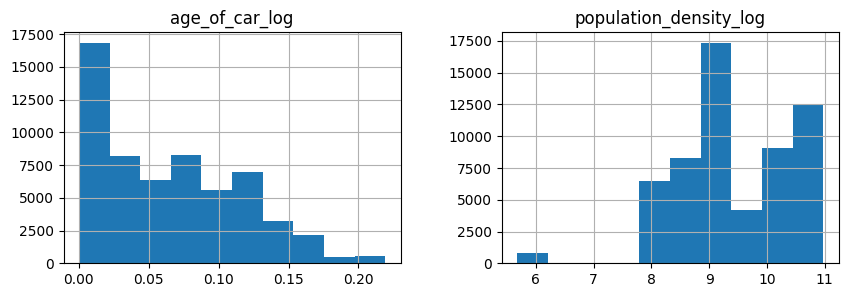

In [15]:
skew_cols = num_cols + ['gear_box', 'height']
print("Skewness — before vs after IQR capping:\n")
print(pd.DataFrame({'before_capping': skew_before.reindex(skew_cols),
                    'after_capping':  ins[skew_cols].skew()}).round(2).to_string(), '\n')

# log1p = log(1 + x), safe for zero values like brand-new cars (age_of_car = 0)
ins['age_of_car_log'] = np.log1p(ins['age_of_car'])

# Compress the long right tail of cluster-level population density
ins['population_density_log'] = np.log1p(ins['population_density'])

print("Before transform:", ins[['age_of_car', 'population_density']].skew().round(2).values)
print("After transform: ", ins[['age_of_car_log', 'population_density_log']].skew().round(2).values, '\n')

# Visual check
ins[['age_of_car_log', 'population_density_log']].hist(figsize=(10, 3))
plt.show()

### **Interpretation — Skewness**

1. Capping at the IQR fences already reduced skewness substantially
(population_density 1.67 → 1.16, age_of_car 1.09 → 0.65).

2. Only population_density remains above the |skew| > 1 threshold; log1p reduces it to -0.57 (acceptable). The raw column is retained for EDA, the log version for modelling.

3. age_of_car (0.65), age_of_policyholder (0.62), and policy_tenure (0.05) are within the moderate/acceptable range post-capping — no transformation applied.

4. Vehicle-spec columns: gear_box (1.18) and height (1.04) exceed the |skew| > 1 threshold, but no transform is applied. As established in the outlier section, these are model-level constants with only 2–11 distinct values — the "skew" is portfolio composition (which models sell more), not distributional shape. A log transform cannot normalise a two-value column and would only destroy interpretability. All other spec columns are below 1.

### Label-Encode Binary Flags to 0/1

`transmission_type`, `rear_brakes_type` and `steering_type` are deliberately **left as text here** —
they are one-hot encoded in the final encoding section along with the other nominal columns,
and keeping them readable makes the EDA plots below far easier to interpret.


In [16]:
# Map every detected Yes/No flag to 0/1
for col in yes_no_cols:
    ins[col] = ins[col].map({'Yes': 1, 'No': 0})

# ---------- Confirm no Yes/No strings remain anywhere ----------
leftover = [c for c in ins.select_dtypes(exclude=np.number).columns
            if ins[c].isin(['Yes', 'No']).any()]

print(f"Flag columns encoded: {len(yes_no_cols)}")
print(f"NaNs introduced by the mapping: {ins[yes_no_cols].isna().sum().sum()}")
print(f"Distinct values now present in flag columns: {sorted(pd.unique(ins[yes_no_cols].values.ravel()))}")
print(f"Columns still containing 'Yes'/'No' strings: {leftover if leftover else 'none'}")

Flag columns encoded: 17
NaNs introduced by the mapping: 0
Distinct values now present in flag columns: [np.int64(0), np.int64(1)]
Columns still containing 'Yes'/'No' strings: none


# Task 1.3 — Exploratory Data Analysis

## Univariate Analysis

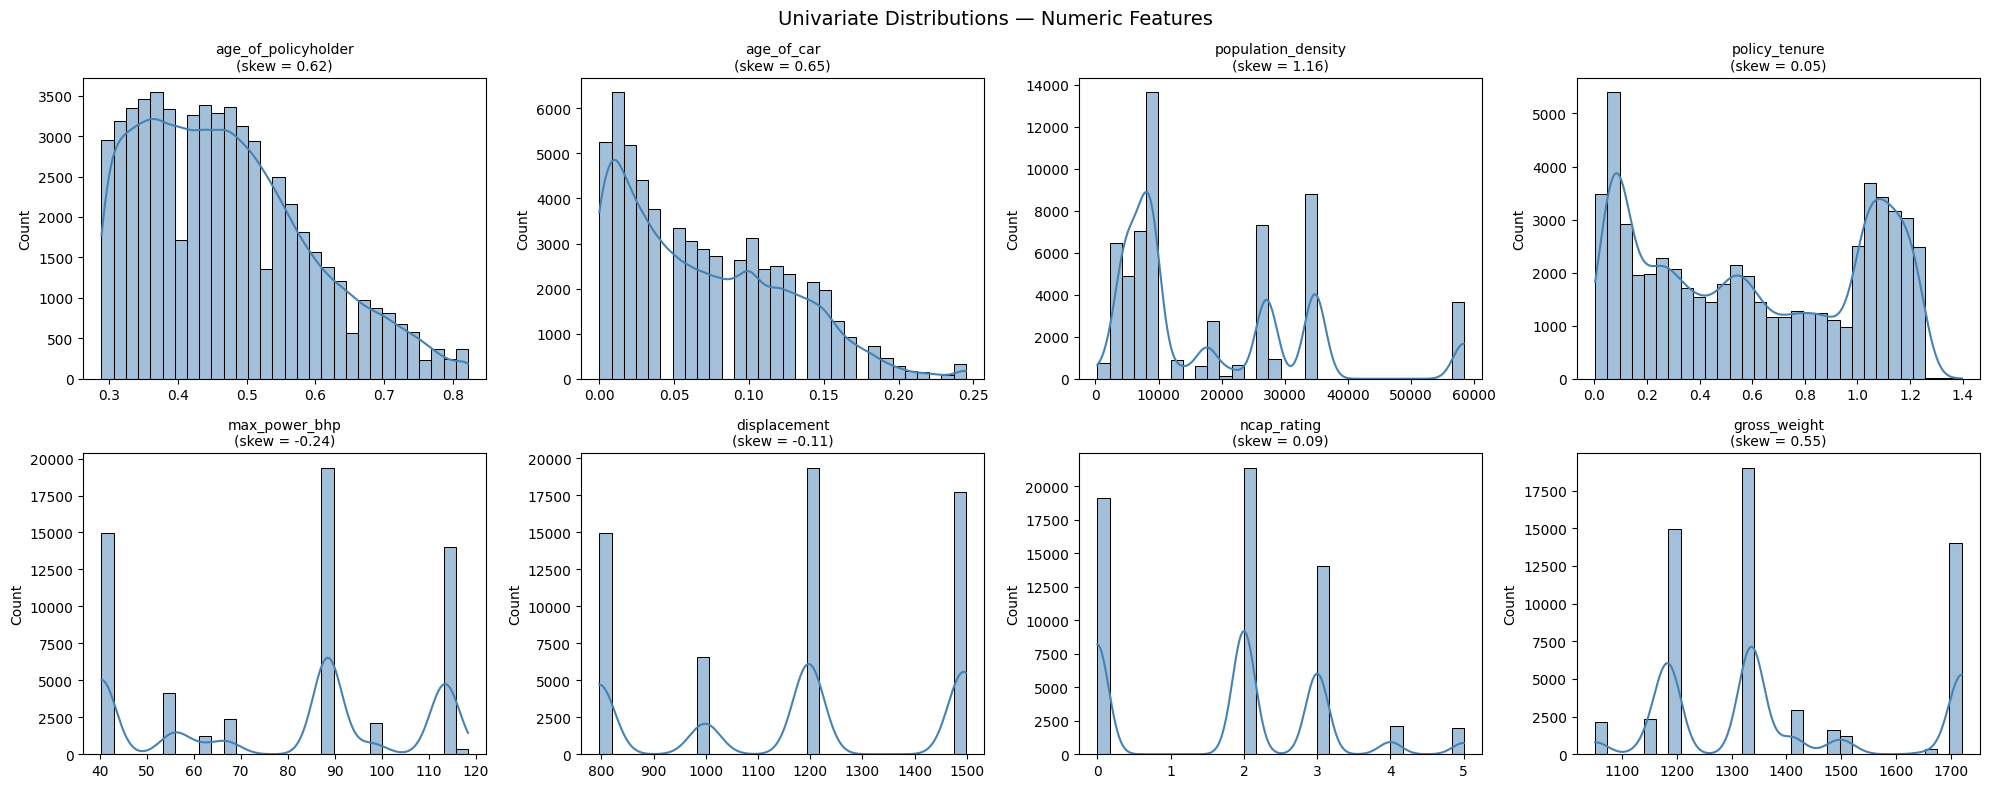

,age_of_policyholder,age_of_car,population_density,policy_tenure,max_power_bhp,displacement,ncap_rating,gross_weight
count,58592.00,58592.00,58592.00,58592.00,58592.00,58592.00,58592.00,58592.00
mean,0.47,0.07,17953.59,0.61,78.98,1162.36,1.76,1385.28
std,0.12,0.06,15146.18,0.41,27.70,266.30,1.39,212.42
min,0.29,0.00,290.00,0.00,40.36,796.00,0.00,1051.00
25%,0.37,0.02,6112.00,0.21,40.36,796.00,0.00,1185.00
50%,0.45,0.06,8794.00,0.57,88.50,1197.00,2.00,1335.00
75%,0.55,0.11,27003.00,1.04,97.89,1493.00,3.00,1510.00
max,0.82,0.24,58339.50,1.40,118.36,1498.00,5.00,1720.00


In [17]:
# ---------- Numeric features: histogram + KDE ----------
eda_numeric = ['age_of_policyholder', 'age_of_car', 'population_density',
               'policy_tenure', 'max_power_bhp', 'displacement',
               'ncap_rating', 'gross_weight']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.ravel(), eda_numeric):
    sns.histplot(ins[col], kde=True, ax=ax, bins=30, color='steelblue')
    ax.set_title(f'{col}\n(skew = {ins[col].skew():.2f})', fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Univariate Distributions — Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

# Five-number summary + mean
display(ins[eda_numeric].describe().round(2))

Interpretations- Univariate Analysis Numerical columns

1. **policy_tenure** ranges from ~0 to ~1.4 with mean ≈ 0.61 and a roughly symmetric distribution (skew 0.05) — the portfolio holds a healthy mix of new and mature policies, with no concentration at either extreme.
2. **age_of_policyholder** is centred around 0.45 (median ≈ 0.45) with most customers between 0.37 and 0.55 and a right tail up to the capped maximum of 0.82 — a middle-aged core with a smaller group of older policyholders.
3. **age_of_car** is heavily concentrated near 0 — most insured vehicles are relatively new (75% below ~0.11), with values extending to the capped maximum of 0.24. This matches expectations for an active portfolio dominated by recent purchases.
4. **population_density** (shown on the log scale after transformation) is not an individual-level measure: it takes only 22 unique values, one per area cluster. Most policies sit in low-to-mid density areas (raw median ≈ 8,800), with the densest metro clusters capped at the IQR fence (≈ 58,300).

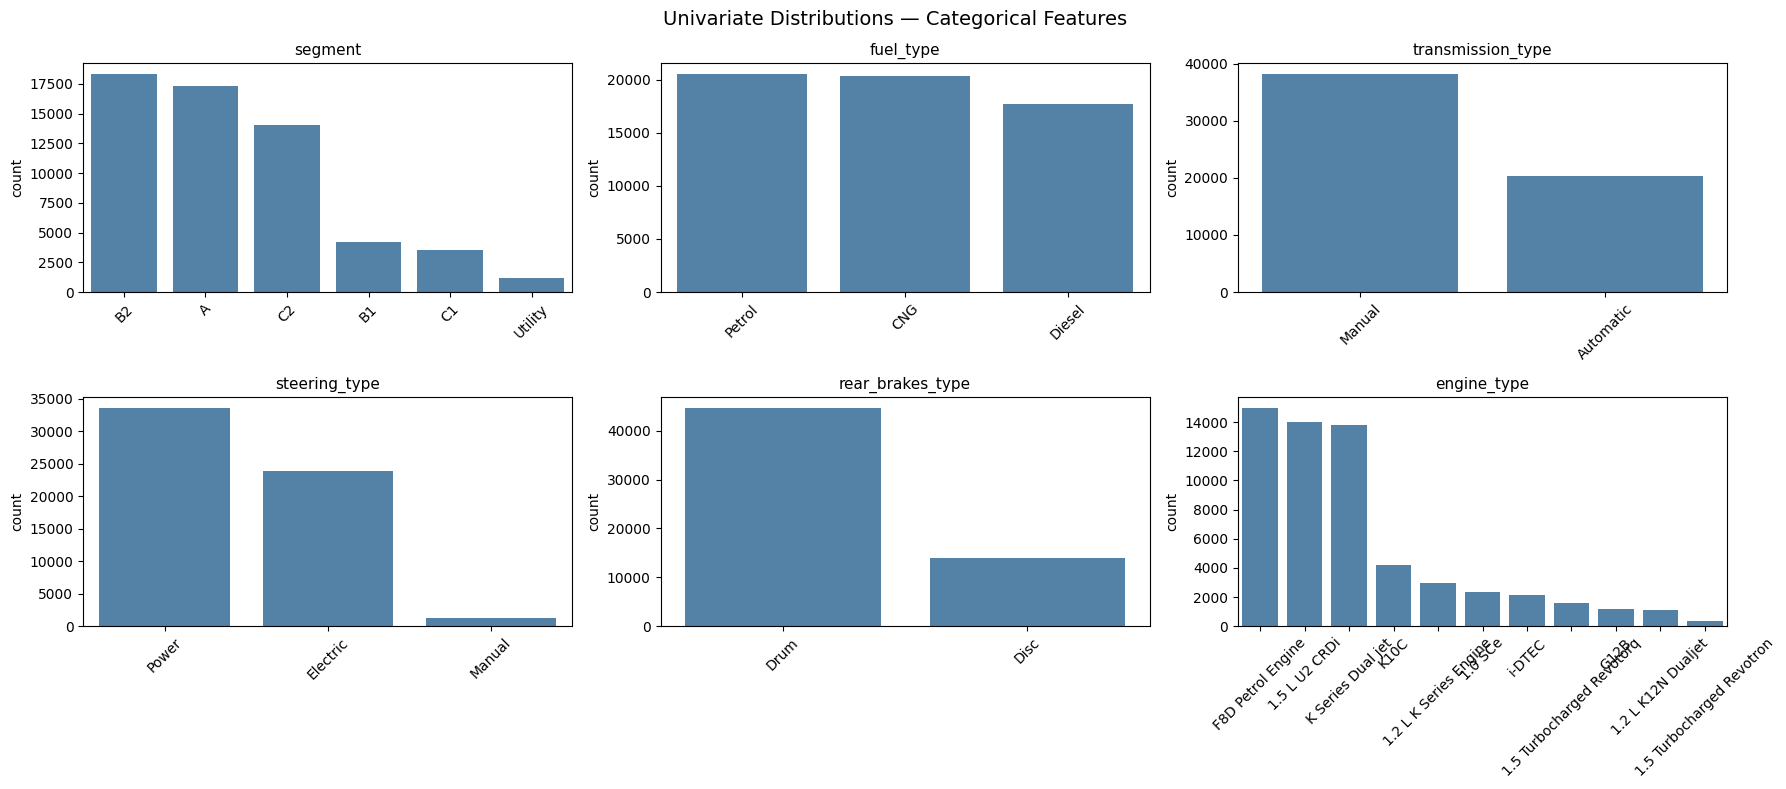

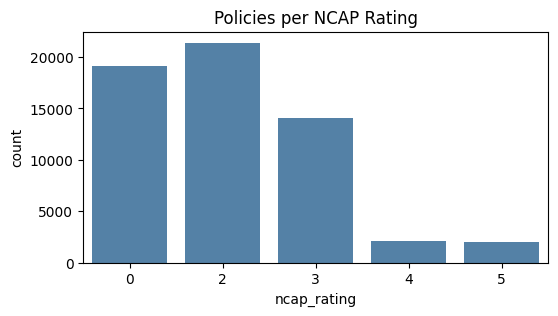

In [18]:
# ---------- Categorical features: count plots ----------
eda_categorical = ['segment', 'fuel_type', 'transmission_type',
                   'steering_type', 'rear_brakes_type', 'engine_type']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.ravel(), eda_categorical):
    order = ins[col].value_counts().index
    sns.countplot(data=ins, x=col, order=order, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Univariate Distributions — Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

# NCAP rating is ordinal but behaves categorically — shown separately
plt.figure(figsize=(6, 3))
sns.countplot(data=ins, x='ncap_rating', color='steelblue')
plt.title('Policies per NCAP Rating')
plt.show()

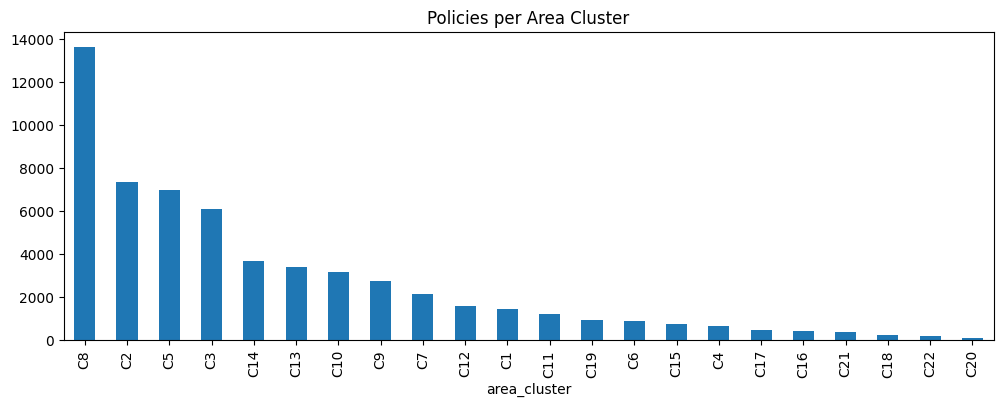

In [19]:
# Geographic Distribution — Area Clusters


ins['area_cluster'].value_counts().plot(kind='bar', figsize=(12, 4), title='Policies per Area Cluster')
plt.show()

### Interpretation — Categorical Variables
1. **Segment:** The portfolio is dominated by compact segments — B2 and A together account for over 60% of policies, followed by C2. B1, C1, and Utility are small minorities — SafeDrive's book skews strongly toward small/budget cars.

2. **Fuel type:** The portfolio is fairly balanced across the three fuel types
([Petrol] ~20.5k, [CNG] ~20.4k, [Diesel] ~17.8k) — no single fuel dominates.

3. **NCAP rating:** Safety ratings skew low — 2 stars and 0  are the most common, with only ~4k vehicles rated 4-5 stars. A rating of 0 most likely indicates an *unrated* model rather than a genuine zero score — worth remembering when the model treats this column as numeric.

4. **Transmission:** Manual (0) dominates with ~38k policies versus ~20.5k Automatic.

5. **Geography:** The portfolio is heavily concentrated — C8 alone holds       ~ 13.6k policies (~23% of the book), and the top four clusters (C8, C2, C5, C3) cover more than half. The tail of small clusters (C18, C22, C20) holds only a few hundred each. Notably, the two high-density metro clusters flagged earlier are mid-to-small in policy count (C10 ~3.2k, C17 ~0.5k) — high density ≠ high policy volume.

## Bivariate Analysis — Target vs Key Predictors

In [20]:
# Bivariate Analysis — Claim Rate vs Key Predictors

def claim_rate_plot(grouper, title):
    rates = ins.groupby(grouper)['is_claim'].mean().round(4)
    print(f"{title}:\n{rates}\n")
    rates.sort_values(ascending=False).plot(kind='bar', figsize=(8, 3), title=title)
    plt.axhline(ins['is_claim'].mean(), color='red', linestyle='--')
    plt.ylabel('claim rate')
    plt.show()


Claim Rate by age_of_policyholder (quintiles):
age_of_policyholder
(0.287, 0.356]    0.0559
(0.356, 0.423]    0.0611
(0.423, 0.49]     0.0683
(0.49, 0.567]     0.0651
(0.567, 0.822]    0.0705
Name: is_claim, dtype: float64



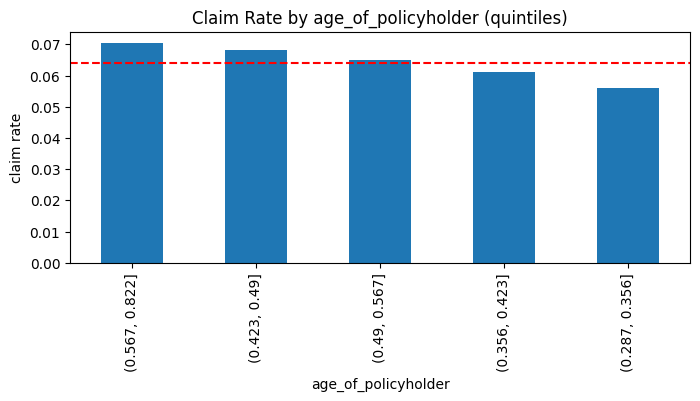

Claim Rate by age_of_car (quintiles):
age_of_car
(-0.001, 0.02]    0.0694
(0.02, 0.04]      0.0636
(0.04, 0.08]      0.0676
(0.08, 0.12]      0.0654
(0.12, 0.245]     0.0504
Name: is_claim, dtype: float64



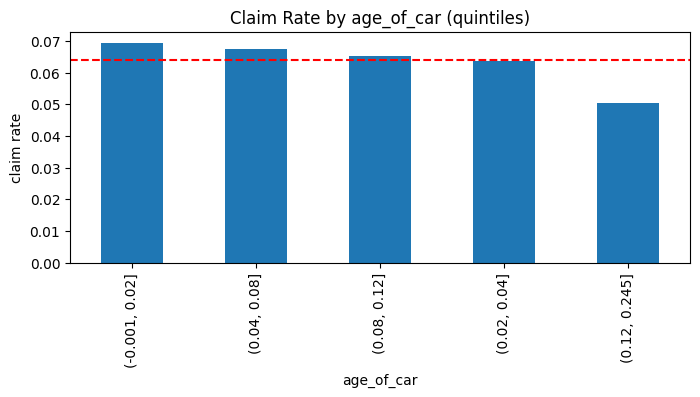

Claim Rate by population_density (quintiles):
population_density
(289.999, 5410.0]     0.0635
(5410.0, 8794.0]      0.0684
(8794.0, 17804.0]     0.0546
(17804.0, 34738.0]    0.0654
(34738.0, 58339.5]    0.0511
Name: is_claim, dtype: float64



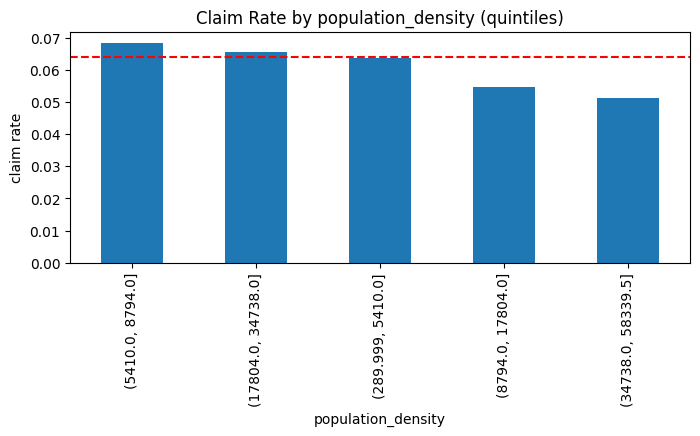

Claim Rate by policy_tenure (quintiles):
policy_tenure
(0.0017399999999999998, 0.14]    0.0358
(0.14, 0.424]                    0.0474
(0.424, 0.773]                   0.0666
(0.773, 1.077]                   0.0865
(1.077, 1.397]                   0.0835
Name: is_claim, dtype: float64



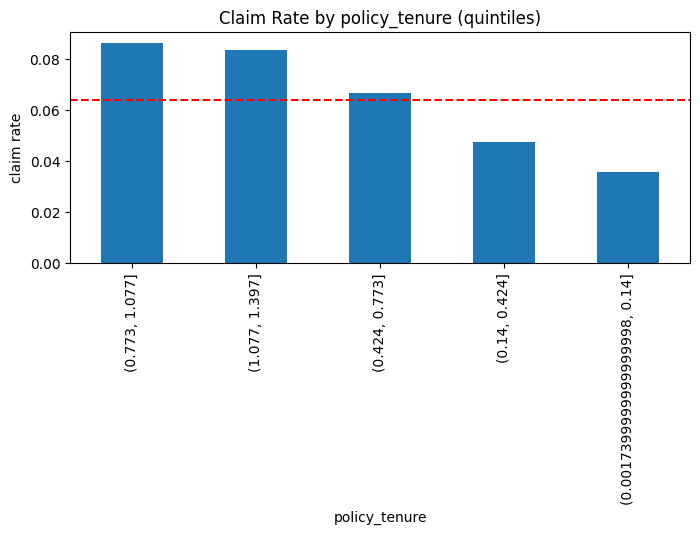

Claim Rate by is_speed_alert:
is_speed_alert
0    0.0413
1    0.0641
Name: is_claim, dtype: float64



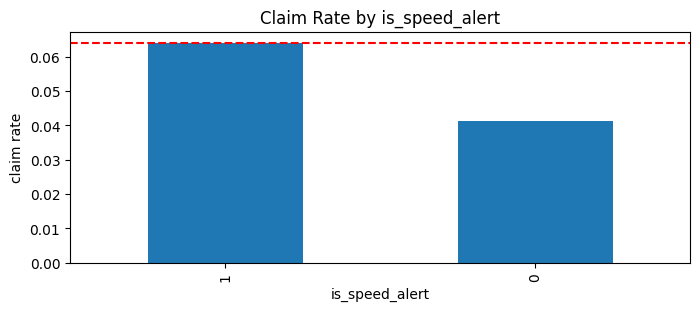

Claim Rate by segment:
segment
A          0.0604
B1         0.0585
B2         0.0686
C1         0.0641
C2         0.0643
Utility    0.0604
Name: is_claim, dtype: float64



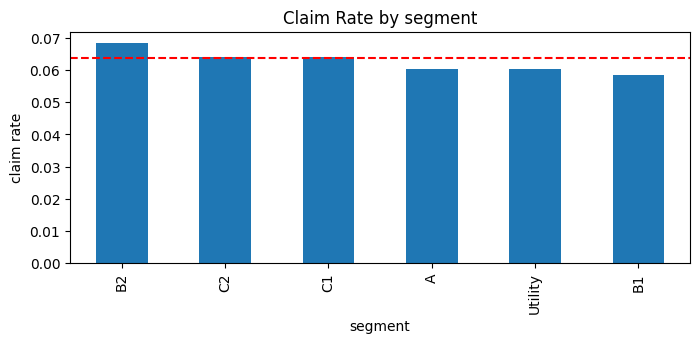

Claim Rate by fuel_type:
fuel_type
CNG       0.0607
Diesel    0.0649
Petrol    0.0664
Name: is_claim, dtype: float64



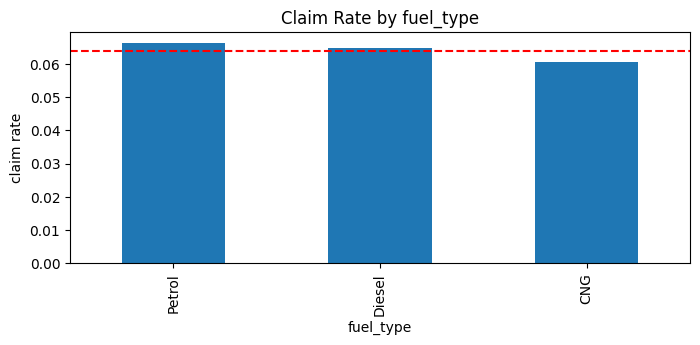

Claim Rate by transmission_type:
transmission_type
Automatic    0.0642
Manual       0.0639
Name: is_claim, dtype: float64



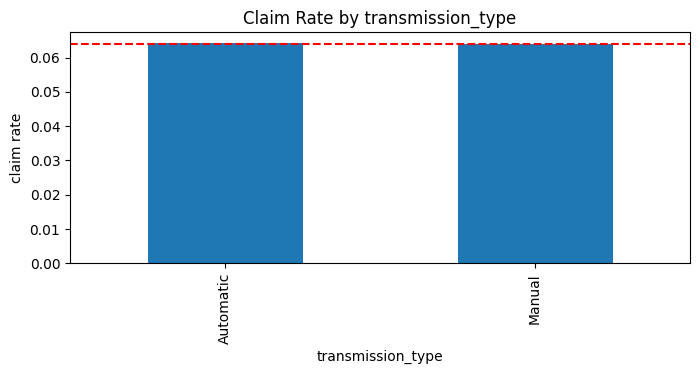

Claim Rate by ncap_rating:
ncap_rating
0    0.0624
2    0.0650
3    0.0643
4    0.0629
5    0.0668
Name: is_claim, dtype: float64



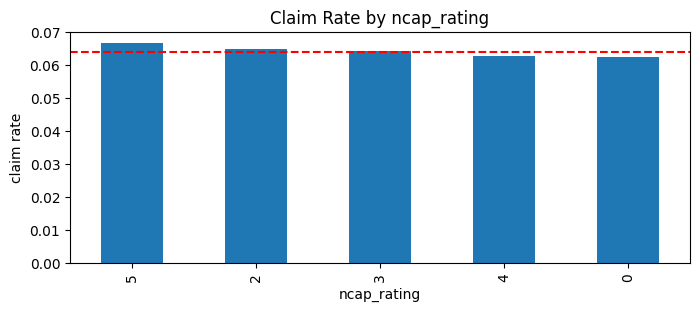

Claim Rate by area_cluster:
area_cluster
C1     0.0518
C10    0.0469
C11    0.0594
C12    0.0548
C13    0.0570
C14    0.0768
C15    0.0493
C16    0.0574
C17    0.0386
C18    0.1074
C19    0.0746
C2     0.0708
C20    0.0459
C21    0.0765
C22    0.0821
C3     0.0710
C4     0.0767
C5     0.0577
C6     0.0618
C7     0.0503
C8     0.0699
C9     0.0497
Name: is_claim, dtype: float64



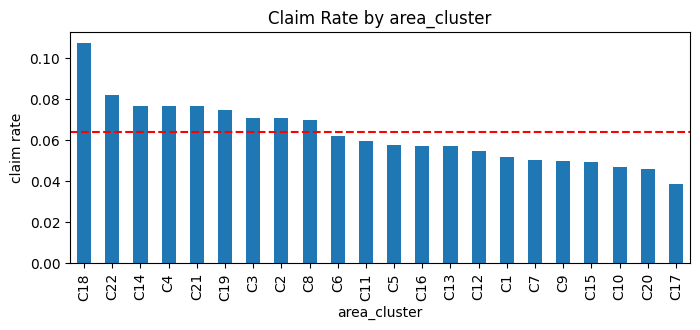

Policies per area cluster (smallest clusters give the noisiest rates):
area_cluster
C17    492
C16    401
C21    379
C18    242
C22    207
C20    109
Name: count, dtype: int64


In [21]:
# ---------- Continuous predictors — quintile bins (equal-count) ----------
# qcut gives equal-sized bins, so every claim rate is computed on a comparable
# number of policies; duplicates='drop' guards against repeated bin edges.

for col in ['age_of_policyholder', 'age_of_car', 'population_density', 'policy_tenure']:
    claim_rate_plot(pd.qcut(ins[col], q=5, duplicates='drop'),
                    f'Claim Rate by {col} (quintiles)')

# ---------- Categorical predictors ----------
for col in ['is_speed_alert', 'segment', 'fuel_type', 'transmission_type',
            'ncap_rating', 'area_cluster']:
    claim_rate_plot(ins[col], f'Claim Rate by {col}')

# Cluster sizes, to caveat the extreme rates
print("Policies per area cluster (smallest clusters give the noisiest rates):")
print(ins['area_cluster'].value_counts().tail(6))

In [22]:
# ---------- Equal-width companion to the quintile view above ----------
# qcut gives equal-COUNT bins: every rate rests on the same sample size, which is
# what makes the rates comparable. pd.cut gives equal-WIDTH bins, which answer a
# different question — at what VALUE of the predictor does risk actually jump?

for col in ['age_of_policyholder', 'policy_tenure', 'age_of_car']:
    rates = ins.groupby(pd.cut(ins[col], 5), observed=True)['is_claim'].mean().round(4)
    print(f"Claim rate by {col} — equal-width bands:\n{rates}\n")

Claim rate by age_of_policyholder — equal-width bands:
age_of_policyholder
(0.288, 0.395]    0.0570
(0.395, 0.502]    0.0672
(0.502, 0.609]    0.0645
(0.609, 0.715]    0.0689
(0.715, 0.822]    0.0817
Name: is_claim, dtype: float64

Claim rate by policy_tenure — equal-width bands:
policy_tenure
(0.00134, 0.282]    0.0386
(0.282, 0.56]       0.0582
(0.56, 0.839]       0.0694
(0.839, 1.118]      0.0871
(1.118, 1.397]      0.0840
Name: is_claim, dtype: float64

Claim rate by age_of_car — equal-width bands:
age_of_car
(-0.000245, 0.049]    0.0675
(0.049, 0.098]        0.0668
(0.098, 0.147]        0.0637
(0.147, 0.196]        0.0440
(0.196, 0.245]        0.0456
Name: is_claim, dtype: float64



### **Interpretation — Bivariate Analysis**

1. **Policyholder age (moderate-strong ↑):** Claim rate trends upward with age — from 5.7% in the youngest band to 8.2% in the oldest (0.715–0.822], vs the 6.4% portfolio average (≈1.4×). After capping, extreme senior values sit at the 0.82 fence, concentrating the elevated risk in a single top band; the middle bands hover near the average (6.5–6.9%).

2. **Vehicle age (mild ↓):** Claim rate declines with vehicle age — the three newest bands sit near the average (6.4–6.8%) while the two oldest bands (age > 0.147) drop to 4.4–4.6%. Quantile bins confirm the same pattern (oldest quintile 5.0%). Older cars claim less.

3. **Policy tenure (strong):** The strongest pattern after age — claim rate climbs from 3.9% in the shortest-tenure band to 8.7% at (0.84–1.12], roughly 2.3×, plateauing at 8.4% in the longest band. Longer-standing policies claim substantially more. (Caveat: tenure partly reflects exposure — a policy held longer has had more time to generate a claim.)

4. **NCAP rating (no effect):** Claim rates are flat across all ratings (6.2%–6.7%), including unrated (0) vehicles. Counter-intuitively, crash-safety rating shows no relationship with claim frequency — plausibly because NCAP measures occupant protection in a crash, not the probability of a claim event occurring.

5. **Segment (weak):** A narrow spread from B1 (5.9%) to B2 (6.9%). B2 — also the largest segment — is the only one meaningfully above average.

6. **Fuel type (negligible):** CNG 6.1%, Diesel 6.5%, Petrol 6.6% — differences too small to matter on their own.

7. **Area cluster (moderate, size-caveated):** Rates range from 3.9% (C17) to 10.7% (C18). However, the extreme clusters are small (C18: 242 policies, C22: 207, C20:109), so their rates are noisy. Among large clusters, C14 (7.7%) runs high and C10 (4.7%) runs low; the dominant C8 (23% of the portfolio) sits slightly above average at 7.0%. Notably, the two high-density metro clusters (C10, C17) are among the lowest-risk areas — consistent with the earlier outlier analysis.

### Validating the Business Questions (Task 1.1)

- **Q1 — Do policyholder age and policy tenure relate to claim likelihood?**  Confirmed: claim rate trends upward with age (5.7% → 8.2%) and rises strongly with tenure (3.9% → 8.7%) — the two clearest risk drivers found in EDA, and their combination (tenure × age) separates risk even further (see Task 1.4).

- **Q2 — Do vehicle safety attributes reduce claim frequency?**
❌ Challenged: NCAP rating shows no relationship with claim rate (flat at 6.2–6.7% across all ratings, including unrated vehicles).

- **Q3 — Are certain geographies systematically riskier?**
⚠️ Partially: cluster rates range 3.9%–10.7%, but the extremes come from small clusters; among large clusters the spread is modest (4.7%–7.7%), with the dominant C8 slightly above average.

## Correlation Analysis

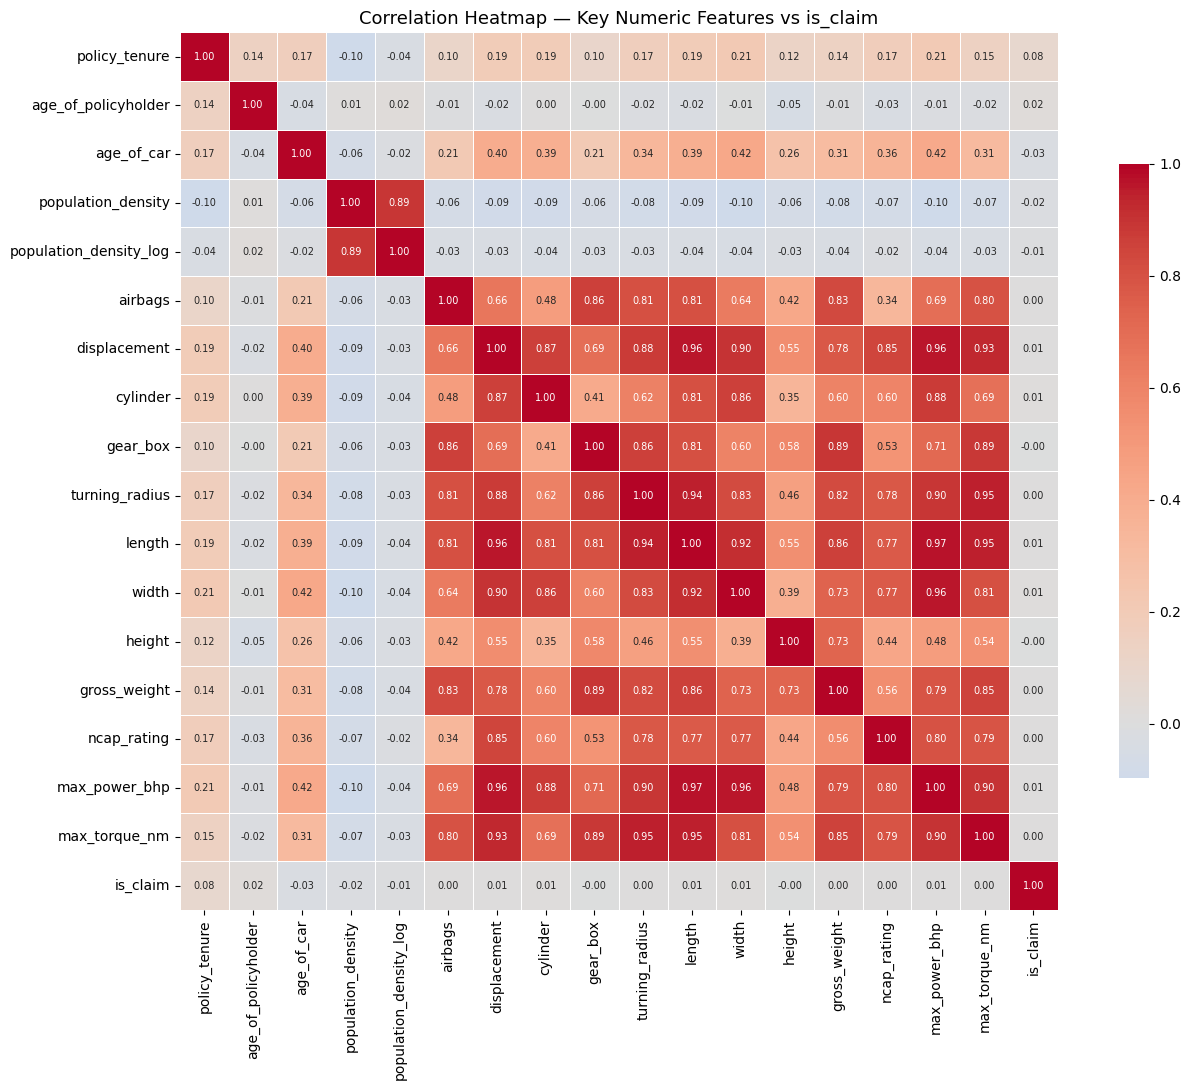

In [23]:
# ---------- Correlation heatmap across key numeric features + the target ----------
corr_features = ['policy_tenure', 'age_of_policyholder', 'age_of_car',
                 'population_density', 'population_density_log',
                 'airbags', 'displacement', 'cylinder', 'gear_box', 'turning_radius',
                 'length', 'width', 'height', 'gross_weight', 'ncap_rating',
                 'max_power_bhp', 'max_torque_nm', 'is_claim']

corr_matrix = ins[corr_features].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7})
plt.title('Correlation Heatmap — Key Numeric Features vs is_claim', fontsize=13)
plt.tight_layout()
plt.show()

Features ranked by |correlation| with is_claim:



,corr_with_is_claim,abs_corr,direction
policy_tenure,0.0787,0.0787,increases claim risk
age_of_car,-0.0282,0.0282,decreases claim risk
age_of_policyholder,0.0223,0.0223,increases claim risk
population_density,-0.0166,0.0166,decreases claim risk
cylinder,0.0134,0.0134,increases claim risk
width,0.0099,0.0099,increases claim risk
population_density_log,-0.0086,0.0086,decreases claim risk
max_power_bhp,0.0077,0.0077,increases claim risk
displacement,0.0077,0.0077,increases claim risk
length,0.0065,0.0065,increases claim risk


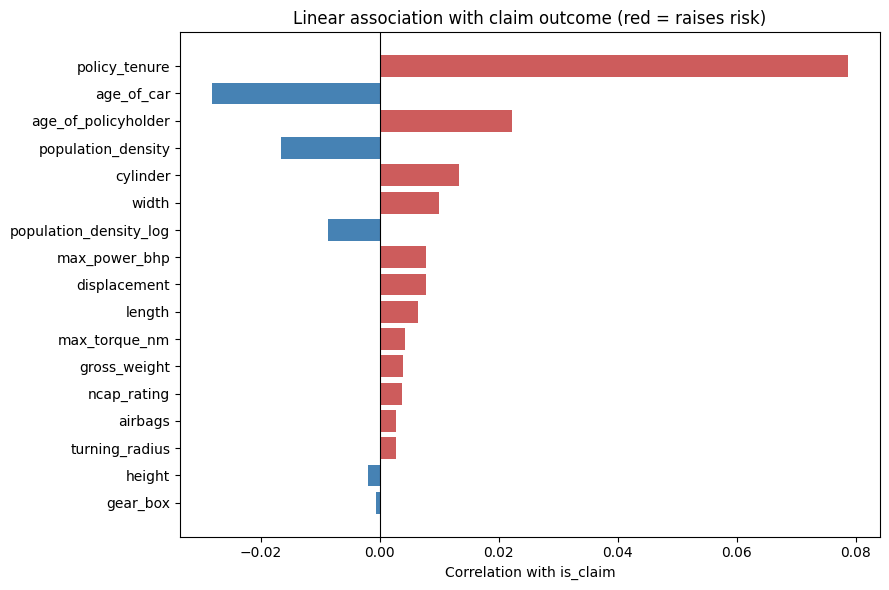

In [24]:
# ---------- Rank features by absolute correlation with the target ----------
target_corr = (corr_matrix['is_claim']
               .drop('is_claim')
               .to_frame('corr_with_is_claim'))
target_corr['abs_corr'] = target_corr['corr_with_is_claim'].abs()
target_corr['direction'] = np.where(target_corr['corr_with_is_claim'] > 0,
                                    'increases claim risk', 'decreases claim risk')
target_corr = target_corr.sort_values('abs_corr', ascending=False).round(4)

print("Features ranked by |correlation| with is_claim:\n")
display(target_corr)

# Visual ranking
plt.figure(figsize=(9, 6))
colors = ['indianred' if v > 0 else 'steelblue' for v in target_corr['corr_with_is_claim']]
plt.barh(target_corr.index[::-1], target_corr['corr_with_is_claim'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with is_claim')
plt.title('Linear association with claim outcome (red = raises risk)')
plt.tight_layout()
plt.show()

### Interpretation — Correlation Analysis

1. **`policy_tenure` is the single strongest linear signal (r = +0.079)** — roughly three times
   stronger than the next feature. It is the only variable whose linear association with the target
   is meaningful on its own, and it matches the 2.3x claim-rate spread seen in the bivariate plots.

2. **`age_of_car` (r = -0.028) and `age_of_policyholder` (r = +0.022)** follow, in the directions
   the claim-rate plots showed: older cars claim less, older policyholders claim more.

3. **Every vehicle-specification feature is essentially uncorrelated with claims** (|r| < 0.014 for
   `displacement`, `gross_weight`, `ncap_rating`, `airbags`, `max_power_bhp`). This reinforces the
   Q2 finding: what the customer drives says far less about claim likelihood than who they are and
   how long they have held the policy.

4. **The vehicle-spec block is heavily inter-correlated**— the top-left cluster of the heatmap shows
length, width, displacement, max_power_bhp, max_torque_nm and turning_radius forming a
dense block in which many pairs exceed 0.9 (fourteen such pairs are listed in the de-duplication
step below), because they are model-level constants rather than per-policy measurements. This is
severe multicollinearity and is dealt with explicitly before the VIF step below.

5. **Caveat on magnitude:** all correlations are small in absolute terms. Pearson correlation
   measures *linear* association with a rare binary outcome, so it understates non-linear and
   interaction effects — it is used here to rank and screen features, not to conclude that the
   dataset lacks signal.


# Task 1.4 — Feature Engineering

Three business-relevant derived features are built first, then the two EDA-driven features
and the interaction term. Every feature is validated against the claim rate before it is kept.


In [25]:
# ==================================================================
# 1. High_Risk_Driver_Flag
#    Youngest quartile of policyholders driving a poorly-rated vehicle
#    (ncap_rating <= 2). Business logic: inexperienced driver + weak
#    vehicle safety is the classic underwriting red flag.
# ==================================================================
age_q1 = ins['age_of_policyholder'].quantile(0.25)

ins['High_Risk_Driver_Flag'] = (
    (ins['age_of_policyholder'] <= age_q1) & (ins['ncap_rating'] <= 2)
).astype(int)

print(f"Bottom-quartile policyholder age cut-off: {age_q1:.4f}")
print(ins['High_Risk_Driver_Flag'].value_counts().rename('policies'), '\n')
print("Claim rate by High_Risk_Driver_Flag:")
print(ins.groupby('High_Risk_Driver_Flag')['is_claim'].mean().round(4), '\n')


# ==================================================================
# 2. safety_equipment_count
#    How much safety kit the vehicle actually carries — sum of every
#    binary safety flag. A single ordinal proxy for trim/equipment level.
# ==================================================================
safety_flag_cols = [c for c in yes_no_cols if c != 'is_claim']
ins['safety_equipment_count'] = ins[safety_flag_cols].sum(axis=1)

print(f"safety_equipment_count built from {len(safety_flag_cols)} binary safety flags")
print(f"Range: {ins['safety_equipment_count'].min()} – {ins['safety_equipment_count'].max()}\n")
print("Claim rate by safety_equipment_count quintile:")
print(ins.groupby(pd.qcut(ins['safety_equipment_count'], 5, duplicates='drop'))['is_claim'].mean().round(4), '\n')


# ==================================================================
# 3. power_to_weight
#    Performance relative to mass — a proxy for how briskly the vehicle
#    can be driven, which is not captured by power or weight alone.
# ==================================================================
ins['power_to_weight'] = ins['max_power_bhp'] / ins['gross_weight']

print("Claim rate by power_to_weight quintile:")
print(ins.groupby(pd.qcut(ins['power_to_weight'], 5, duplicates='drop'))['is_claim'].mean().round(4))

Bottom-quartile policyholder age cut-off: 0.3654
High_Risk_Driver_Flag
0    48554
1    10038
Name: policies, dtype: int64 

Claim rate by High_Risk_Driver_Flag:
High_Risk_Driver_Flag
0    0.0655
1    0.0565
Name: is_claim, dtype: float64 

safety_equipment_count built from 17 binary safety flags
Range: 2 – 16

Claim rate by safety_equipment_count quintile:
safety_equipment_count
(1.999, 3.0]    0.0613
(3.0, 7.0]      0.0599
(7.0, 11.0]     0.0675
(11.0, 16.0]    0.0653
Name: is_claim, dtype: float64 

Claim rate by power_to_weight quintile:
power_to_weight
(0.0331, 0.0596]    0.0609
(0.0596, 0.066]     0.0650
(0.066, 0.0663]     0.0686
(0.0663, 0.0931]    0.0597
Name: is_claim, dtype: float64


In [26]:
# ==================================================================
# 4-6. EDA-driven features (thresholds taken from the bivariate plots)
# ==================================================================

# Seniors flag: top age band (0.715–0.822] claims at 8.2% vs 6.4% average
ins['is_senior'] = (ins['age_of_policyholder'] > 0.7).astype(int)

# Long-tenure flag: top tenure bands claim at 8.7% / 8.4%
ins['is_long_tenure'] = (ins['policy_tenure'] > 0.84).astype(int)

# Interaction of the two strongest EDA drivers
ins['tenure_age_interaction'] = ins['policy_tenure'] * ins['age_of_policyholder']

engineered = ['High_Risk_Driver_Flag', 'safety_equipment_count', 'power_to_weight',
              'is_senior', 'is_long_tenure', 'tenure_age_interaction']

# Claim rate for each binary flag
for col in ['High_Risk_Driver_Flag', 'is_senior', 'is_long_tenure']:
    rates = ins.groupby(col)['is_claim'].mean().round(4)
    print(f"{col}: {rates.to_dict()}  (lift = {rates[1] / rates[0]:.2f}x)")

# Claim rate by quintile for the continuous ones
print()
for col in ['tenure_age_interaction', 'safety_equipment_count', 'power_to_weight']:
    q = ins.groupby(pd.qcut(ins[col], 5, duplicates='drop'))['is_claim'].mean().round(4)
    print(f"{col}: {q.min():.4f} -> {q.max():.4f}  (spread = {q.max() / q.min():.2f}x)")

High_Risk_Driver_Flag: {0: 0.0655, 1: 0.0565}  (lift = 0.86x)
is_senior: {0: 0.0629, 1: 0.0815}  (lift = 1.30x)
is_long_tenure: {0: 0.0512, 1: 0.0857}  (lift = 1.67x)

tenure_age_interaction: 0.0352 -> 0.0883  (spread = 2.51x)
safety_equipment_count: 0.0599 -> 0.0675  (spread = 1.13x)
power_to_weight: 0.0597 -> 0.0686  (spread = 1.15x)


### Feature Engineering — Interpretation

| Feature | Claim-rate behaviour | Verdict |
|---|---|---|
| `tenure_age_interaction` | 3.5% -> 8.8% across quintiles (**2.5x**) — stronger than either parent alone (age 1.4x, tenure 2.3x) | Strongest engineered feature |
| `is_long_tenure` | 5.1% vs 8.6% (**1.7x**) | Clean, interpretable split |
| `is_senior` | 6.3% vs 8.2% (**1.3x**) | Modest but consistent |
| `High_Risk_Driver_Flag` | 5.7% vs 6.6% — flagged group claims **less** | Retained, but see note below |
| `safety_equipment_count` | 6.0%–6.8%, non-monotonic | Little standalone signal |
| `power_to_weight` | 6.0%–6.9%, non-monotonic | Little standalone signal |

**Note on `High_Risk_Driver_Flag`.** Built exactly to the intended business definition —
bottom-quartile policyholder age **and** `ncap_rating <= 2` — the flag turns out to move in the
*opposite* direction to its name: flagged policies claim at 5.7% against 6.6% for everyone else.
Both components explain why. The bivariate analysis showed claim rate rising with policyholder
age rather than falling, and NCAP rating showed no relationship with claim frequency at all
(6.2%–6.7% flat). This is a genuine and reportable finding: **the conventional
"young driver in an unsafe car" underwriting heuristic does not hold in this portfolio.** The
feature is retained because a consistent inverse relationship is still usable signal for the
model, and because the result itself is a business insight worth putting in front of underwriting.

`safety_equipment_count` and `power_to_weight` show no standalone separation, which — alongside
the flat NCAP result — makes the "vehicle attributes do not predict claim frequency" conclusion
robust across three independent measures. They are carried into the multicollinearity check
rather than dropped on the strength of a univariate look alone, since a feature can still
contribute inside a multivariate model.


## Feature Selection — Near-Duplicate Removal and VIF

Two-step process:

1. **Remove near-duplicate columns** — any pair with `|corr| > 0.9`. The vehicle-spec block is
   badly affected because those columns are model-level constants, so a handful of distinct
   vehicles reproduce each other almost exactly. Feeding these straight into VIF produces
   meaningless four-figure scores.
2. **Compute VIF** on what survives, flag anything above 10, and iterate until the whole set is clean.


In [27]:
# ---------- Step 1: find and remove near-duplicate columns (|corr| > 0.9) ----------

# Raw density is the twin of its log version; the log column is the modelling column
ins = ins.drop(columns=['population_density', 'age_of_car_log'], errors='ignore')

# Candidate numeric features: exclude the target, IDs and binary flags
numeric_candidates = [c for c in ins.select_dtypes(include=np.number).columns
                      if c != 'is_claim' and ins[c].nunique() > 2]

# Absolute correlation with the target — used to decide which twin to keep
target_strength = ins[numeric_candidates + ['is_claim']].corr()['is_claim'].drop('is_claim').abs()

corr_abs = ins[numeric_candidates].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

high_pairs = sorted(
    [(r, c, round(upper.loc[r, c], 3)) for r in upper.index for c in upper.columns
     if pd.notna(upper.loc[r, c]) and upper.loc[r, c] > 0.9],
    key=lambda x: -x[2])

print(f"Found {len(high_pairs)} column pairs with |corr| > 0.9:\n")
print(pd.DataFrame(high_pairs, columns=['feature_1', 'feature_2', '|corr|']).to_string(index=False))

# Drop one from each pair — keep whichever has the stronger link to the target
near_duplicates = set()
for a, b, v in high_pairs:
    if a in near_duplicates or b in near_duplicates:
        continue
    near_duplicates.add(a if target_strength[a] < target_strength[b] else b)

deduped_features = [c for c in numeric_candidates if c not in near_duplicates]

print(f"\nDropped as near-duplicates ({len(near_duplicates)}): {sorted(near_duplicates)}")
print(f"Retained for VIF ({len(deduped_features)}): {deduped_features}")

Found 14 column pairs with |corr| > 0.9:

     feature_1              feature_2  |corr|
        length          max_power_bhp   0.973
  displacement          max_power_bhp   0.963
  displacement                 length   0.962
         width          max_power_bhp   0.960
        length          max_torque_nm   0.952
 max_power_bhp safety_equipment_count   0.951
turning_radius          max_torque_nm   0.947
        length safety_equipment_count   0.946
turning_radius                 length   0.945
         width safety_equipment_count   0.943
  displacement          max_torque_nm   0.931
        length                  width   0.916
 max_torque_nm              power_rpm   0.912
 policy_tenure tenure_age_interaction   0.910

Dropped as near-duplicates (7): ['displacement', 'length', 'max_power_bhp', 'power_rpm', 'safety_equipment_count', 'tenure_age_interaction', 'turning_radius']
Retained for VIF (12): ['policy_tenure', 'age_of_car', 'age_of_policyholder', 'airbags', 'width', 'height', 

In [28]:
# ---------- Step 2: Variance Inflation Factor ----------
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def compute_vif(df, cols):
    """VIF for each column; the constant is added but not reported."""
    X = add_constant(df[cols].astype(float))
    return (pd.DataFrame({
                'feature': cols,
                'VIF': [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]})
            .sort_values('VIF', ascending=False)
            .round(2)
            .reset_index(drop=True))


vif_initial = compute_vif(ins, deduped_features)
vif_initial['problematic (VIF > 10)'] = vif_initial['VIF'] > 10

print("VIF after near-duplicate removal:\n")
display(vif_initial)
print(f"Features still flagged as problematic: {int(vif_initial['VIF'].gt(10).sum())}")

VIF after near-duplicate removal:



,feature,VIF,problematic (VIF > 10)
0,max_torque_nm,236.88,True
1,gross_weight,117.14,True
2,power_to_weight,43.38,True
3,width,37.26,True
4,torque_rpm,23.20,True
5,ncap_rating,21.32,True
6,height,14.32,True
7,airbags,14.00,True
8,age_of_car,1.29,False
9,policy_tenure,1.09,False


Features still flagged as problematic: 8


In [29]:
# ---------- Step 3: iteratively drop the worst offender until every VIF <= 10 ----------
selected = deduped_features.copy()
elimination_log = []

while len(selected) > 2:
    v = compute_vif(ins, selected)
    worst = v.iloc[0]
    if worst['VIF'] <= 10:
        break
    elimination_log.append({'dropped': worst['feature'], 'VIF_at_drop': worst['VIF']})
    selected.remove(worst['feature'])

print("Iterative elimination:")
display(pd.DataFrame(elimination_log))

vif_final = compute_vif(ins, selected)
vif_final['problematic (VIF > 10)'] = vif_final['VIF'] > 10
print("\nFinal VIF table — all values below the threshold of 10:\n")
display(vif_final)

# ---------- Assemble the final feature set ----------
# Two-level numeric columns sit outside the VIF check (no meaningful variance
# inflation on a 0/1 column) but still belong in the modelling feature set.
two_level = [c for c in ins.select_dtypes(include=np.number).columns
             if c != 'is_claim' and ins[c].nunique() <= 2]

final_modeling_features = sorted(selected) + sorted(two_level)

print(f"\nfinal_modeling_features — {len(final_modeling_features)} features")
print(f"\n  Continuous / ordinal ({len(selected)}):")
for f in sorted(selected):
    print("    ", f)
print(f"\n  Binary / two-level features ({len(two_level)}):")
for f in sorted(two_level):
    print("    ", f)
print("\n  Plus the one-hot encoded nominal columns created in the next section.")

Iterative elimination:


,dropped,VIF_at_drop
0,max_torque_nm,236.88
1,width,28.74
2,gross_weight,13.46



Final VIF table — all values below the threshold of 10:



,feature,VIF,problematic (VIF > 10)
0,ncap_rating,3.87,False
1,power_to_weight,3.48,False
2,torque_rpm,1.77,False
3,airbags,1.65,False
4,height,1.60,False
5,age_of_car,1.29,False
6,policy_tenure,1.09,False
7,age_of_policyholder,1.03,False
8,population_density_log,1.00,False



final_modeling_features — 31 features

  Continuous / ordinal (9):
     age_of_car
     age_of_policyholder
     airbags
     height
     ncap_rating
     policy_tenure
     population_density_log
     power_to_weight
     torque_rpm

  Binary / two-level features (22):
     High_Risk_Driver_Flag
     cylinder
     gear_box
     is_adjustable_steering
     is_brake_assist
     is_central_locking
     is_day_night_rear_view_mirror
     is_driver_seat_height_adjustable
     is_ecw
     is_esc
     is_front_fog_lights
     is_long_tenure
     is_parking_camera
     is_parking_sensors
     is_power_door_locks
     is_power_steering
     is_rear_window_defogger
     is_rear_window_washer
     is_rear_window_wiper
     is_senior
     is_speed_alert
     is_tpms

  Plus the one-hot encoded nominal columns created in the next section.


### Interpretation — Feature Selection

1. **The vehicle-spec block was the whole problem.** Fourteen column pairs exceeded `|corr| > 0.9`,
   almost all inside the vehicle specification group (`length`–`max_power_bhp` at 0.97,
   `displacement`–`max_power_bhp` at 0.96, and so on). These columns are attributes of the *vehicle
   model*, not of the individual policy, so a small number of distinct models reproduce one another
   almost perfectly. Before de-duplication the collinearity is perfect — several spec columns are exact linear combinations of others, making VIF undefined. Even after removing the near-duplicates, the worst remaining VIF is 237.

2. **Tie-break rule.** Where a pair was near-identical, the column with the stronger absolute
   correlation to `is_claim` was kept. This is why `policy_tenure` (r = 0.079) is retained over
   `tenure_age_interaction` (r = 0.076) — the two correlate at 0.91, so keeping both would add
   collinearity without adding information. The interaction is worth revisiting in Stage 3, where
   tree-based models are indifferent to multicollinearity.

3. **`safety_equipment_count` was also removed** as a near-duplicate — it correlates at 0.95 with
   `max_power_bhp`, because equipment level tracks trim level, which tracks engine size. It is a
   restatement of "how expensive is this car", not independent information.

4. **The surviving set is clean.** After iterative elimination every VIF sits comfortably below 10
   (highest ≈ 3.9), meaning each retained feature carries information the others do not. Coefficients
   from the Stage 2 logistic regression can therefore be read and explained individually — which is
   exactly what management asked for.

5. **Methodology note.** Engineered thresholds (0.7, 0.84) and the IQR fences were derived from the
   full dataset in line with the project workflow. In production these would be fitted on training
   data only and applied to the test split, and Stage 2 implements the split-aware version.


## Task 1.2 (continued) — Final Encoding and Export

Run after Tasks 1.3 and 1.4 so `cleaned_dataset.csv` reflects the final feature set —
engineered features included, near-duplicates removed.

`drop_first=False` is used deliberately: the downstream models are regularised logistic
regression and a decision tree, neither of which is harmed by the redundant level, and keeping
every category makes the SHAP output in Stage 3 directly readable ("segment B2" rather than
"not any of the other segments").


In [30]:
# All remaining nominal text columns
categorical_cols = ['area_cluster', 'segment', 'fuel_type', 'engine_type',
                    'rear_brakes_type', 'transmission_type', 'steering_type',
                    'model', 'make']
categorical_cols = [c for c in categorical_cols if c in ins.columns]

print("One-hot encoding:", categorical_cols)
print("Cardinality:", {c: ins[c].nunique() for c in categorical_cols})

ins_encoded = pd.get_dummies(ins, columns=categorical_cols, drop_first=False, dtype=int)

# ---------- Verification ----------
print("\nShape before encoding:", ins.shape)
print("Shape after encoding :", ins_encoded.shape)
remaining_text = [c for c in ins_encoded.select_dtypes(exclude=np.number).columns]
print("Text columns remaining:", remaining_text, "(policy_id is the identifier and is expected)")
print("Engineered features present:",
      [c for c in engineered if c in ins_encoded.columns])
print("Dropped columns absent:",
      [c for c in ['population_density', 'max_power', 'max_torque'] if c not in ins_encoded.columns])
print("Missing values:", ins_encoded.isna().sum().sum())

One-hot encoding: ['area_cluster', 'segment', 'fuel_type', 'engine_type', 'rear_brakes_type', 'transmission_type', 'steering_type', 'model', 'make']
Cardinality: {'area_cluster': 22, 'segment': 6, 'fuel_type': 3, 'engine_type': 11, 'rear_brakes_type': 2, 'transmission_type': 2, 'steering_type': 3, 'model': 11, 'make': 5}

Shape before encoding: (58592, 52)
Shape after encoding : (58592, 108)
Text columns remaining: ['policy_id'] (policy_id is the identifier and is expected)
Engineered features present: ['High_Risk_Driver_Flag', 'safety_equipment_count', 'power_to_weight', 'is_senior', 'is_long_tenure', 'tenure_age_interaction']
Dropped columns absent: ['population_density', 'max_power', 'max_torque']
Missing values: 0


In [31]:
# Export the final cleaned, feature-engineered, encoded dataset — submission file #1
ins_encoded.to_csv('cleaned_dataset.csv', index=False)

print(f"Saved cleaned_dataset.csv — {ins_encoded.shape[0]:,} rows x {ins_encoded.shape[1]} columns")
print(f"Claim rate preserved: {ins_encoded['is_claim'].mean():.4f}")

# Persist the VIF-selected feature list for Stage 2
pd.Series(final_modeling_features, name='feature').to_csv('final_modeling_features.csv', index=False)
print(f"Saved final_modeling_features.csv — {len(final_modeling_features)} features")

Saved cleaned_dataset.csv — 58,592 rows x 108 columns
Claim rate preserved: 0.0640
Saved final_modeling_features.csv — 31 features
